In [ ]:
import pandas as pd
import numpy as np
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
train_data = pd.read_csv(
    "train_data.txt",
    sep=" ::: ",
    names=["ID","TITLE","GENRE","DESCRIPTION"],
    engine="python"
)

test_data = pd.read_csv(
    "test_data.txt",
    sep=" ::: ",
    names=["ID","TITLE","DESCRIPTION"],
    engine="python"
)

test_solution = pd.read_csv(
    "test_data_solution.txt",
    sep=" ::: ",
    names=["ID","TITLE","GENRE","DESCRIPTION"],
    engine="python"
)

train_data.head()

,ID,TITLE,GENRE,DESCRIPTION
0,1,Oscar et la dame rose (2009),drama,Listening in to a conversation between his doc...
1,2,Cupid (1997),thriller,A brother and sister with a past incestuous re...
2,3,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fiel...
3,4,The Secret Sin (1915),drama,To help their unemployed father make ends meet...
4,5,The Unrecovered (2007),drama,The film's title refers not only to the un-rec...


In [ ]:
print(train_data.shape)

print(train_data.isnull().sum())

print(train_data['GENRE'].value_counts())

(54214, 6)
ID                   0
TITLE                0
GENRE                0
DESCRIPTION          0
clean_description    0
text                 0
dtype: int64
GENRE
drama          13613
documentary    13096
comedy          7447
short           5073
horror          2204
thriller        1591
action          1315
western         1032
reality-tv       884
family           784
adventure        775
music            731
romance          672
sci-fi           647
adult            590
crime            505
animation        498
sport            432
talk-show        391
fantasy          323
mystery          319
musical          277
biography        265
history          243
game-show        194
news             181
war              132
Name: count, dtype: int64


In [ ]:
print(train_data['GENRE'].value_counts().head(20))

GENRE
drama          13613
documentary    13096
comedy          7447
short           5073
horror          2204
thriller        1591
action          1315
western         1032
reality-tv       884
family           784
adventure        775
music            731
romance          672
sci-fi           647
adult            590
crime            505
animation        498
sport            432
talk-show        391
fantasy          323
Name: count, dtype: int64


In [ ]:
genre_counts = train_data['GENRE'].value_counts()

valid_genres = genre_counts[genre_counts >= 50].index

train_data = train_data[
    train_data['GENRE'].isin(valid_genres)
]

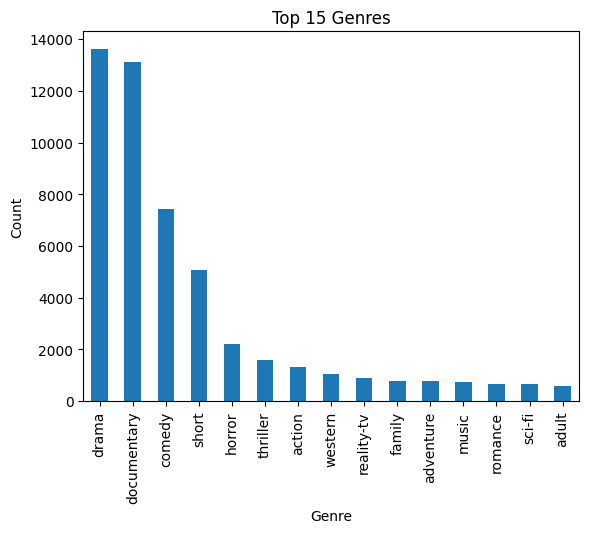

In [ ]:
import matplotlib.pyplot as plt
genre_counts = train_data['GENRE'].value_counts()
genre_counts.head(15).plot(kind='bar')

plt.title('Top 15 Genres')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.show()

In [ ]:
import nltk

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
import re

import nltk
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(tag):

    if tag.startswith('J'):
        return wordnet.ADJ

    elif tag.startswith('V'):
        return wordnet.VERB

    elif tag.startswith('N'):
        return wordnet.NOUN

    elif tag.startswith('R'):
        return wordnet.ADV

    return wordnet.NOUN


def lemmatize_text(text):

    words = text.split()

    tagged_words = pos_tag(words)

    lemmatized = [
        lemmatizer.lemmatize(word, get_wordnet_pos(tag))
        for word, tag in tagged_words
    ]

    return " ".join(lemmatized)
def clean_text(text):

    text = str(text).lower()

    # remove urls
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\b\d{4}\b', ' ', text)
    # remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)


    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # lemmatization
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [ ]:
import nltk

nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [ ]:
train_data['clean_description'] = train_data['DESCRIPTION'].apply(clean_text)

In [ ]:
train_data['TITLE'] = train_data['TITLE'].str.replace(
    r'\(\d{4}\)',
    '',
    regex=True
)
train_data['text'] = (
    train_data['TITLE'].fillna('') + ' ' +
    train_data['clean_description']
)
test_data['text'] = (
    test_data['TITLE'].fillna('') + ' ' +
    test_data['DESCRIPTION'].fillna('')
)

X = train_data['text']
y = train_data['GENRE']

In [ ]:
train_data['text'] = train_data['text'].apply(clean_text)

test_data['text'] = test_data['text'].apply(clean_text)

In [ ]:
X_test = test_data['text']
y_test = test_solution['GENRE']

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

"""tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=150000,
    ngram_range=(1,3),
    min_df=2,
    sublinear_tf=True
)
"""
from sklearn.feature_extraction import text

custom_stopwords = [
    'film',
    'movie',
    'story',
    'year',
    'ha',
    'wa',
    'episode',
    'feature',
    'series'
]

# Combine sklearn's English stopwords with yours
stop_words = list(text.ENGLISH_STOP_WORDS.union(custom_stopwords))
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=150000,
    ngram_range=(1,3),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_word_train= tfidf.fit_transform(X_train)
X_word_test = tfidf.transform(X_test)

In [ ]:
print(X_word_train.shape)
print(X_word_test.shape)

(43371, 150000)
(54200, 150000)


In [ ]:
char_tfidf = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3,5),
    max_features=50000
)

X_char_train = char_tfidf.fit_transform(X_train)
X_char_test = char_tfidf.transform(X_test)

In [ ]:
from scipy.sparse import hstack

X_train_final = hstack([
    X_word_train,
    X_char_train
])

X_test_final = hstack([
    X_word_test,
    X_char_test
])

In [ ]:
from sklearn.svm import LinearSVC


model = LinearSVC(
    class_weight='balanced',
    random_state=42
)

model.fit(X_train_final, y_train)

LinearSVC(class_weight='balanced', random_state=42)

In [ ]:
y_pred = model.predict(X_test_final)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print(classification_report(y_test, y_pred))

Accuracy: 0.5854059040590406
              precision    recall  f1-score   support

      action       0.38      0.46      0.41      1314
       adult       0.50      0.58      0.54       590
   adventure       0.35      0.32      0.33       775
   animation       0.29      0.23      0.25       498
   biography       0.07      0.02      0.03       264
      comedy       0.59      0.59      0.59      7446
       crime       0.18      0.14      0.16       505
 documentary       0.74      0.80      0.77     13096
       drama       0.65      0.61      0.63     13612
      family       0.26      0.24      0.25       783
     fantasy       0.28      0.19      0.22       322
   game-show       0.72      0.69      0.70       193
     history       0.13      0.05      0.08       243
      horror       0.57      0.71      0.63      2204
       music       0.52      0.66      0.59       731
     musical       0.27      0.17      0.21       276
     mystery       0.16      0.09      0.12       31

In [ ]:
feature_names = tfidf.get_feature_names_out()

for genre, coef in zip(model.classes_, model.coef_):

    top_indices = coef.argsort()[-10:]  # Top 10 words

    top_words = [feature_names[i] for i in top_indices]

    print(f"\nGenre: {genre}")
    print(top_words)



Genre: action
['wwe', 'raghuveer', 'jaggu', 'fight', 'martial art', 'vaanmathi', 'ravi', 'ninja', 'assassin', 'martial']

Genre: adult
['private', 'aladdin', 'erotic', 'guy', 'reporter', 'swinger', 'hot', 'anal', 'fantasy', 'sex']

Genre: adventure
['kt', 'thailand', 'bound', 'arvi', 'jungle', 'jael', 'adventure', 'gagged', 'formula', 'bondage']

Genre: animation
['luis', 'masuo', 'claw', 'battu', 'pickwick', 'hank', 'bibee', 'bheem', 'animated', 'bratz']

Genre: comedy
['wedding', 'famous', 'crazy', 'job', 'sketch', 'humor', 'local', 'mockumentary', 'hilarious', 'comedy']

Genre: crime
['dev', 'tanvi', 'uwe', 'ashish', 'gardenia', 'schnell', 'yakuza', 'ronan', 'boris', 'shuhaadh']

Genre: documentary
['examines', 'national', 'unique', 'today', 'state', 'europe', 'people', 'history', 'interview', 'documentary']

Genre: drama
['suicide', 'return', 'love', 'prostitute', 'young', 'father', 'son', 'life', 'relationship', 'drama']

Genre: family
['bailey', 'elf', 'kid', 'mischievous', 'bha

In [ ]:
from collections import Counter

all_words = " ".join(train_data['clean_description']).split()

word_counts = Counter(all_words)

print(word_counts.most_common(50))

[('the', 58514), ('a', 36909), ('and', 33578), ('of', 29203), ('to', 28000), ('in', 19113), ('is', 14496), ('his', 11884), ('s', 10251), ('with', 9125), ('her', 8391), ('he', 8152), ('for', 7319), ('that', 7266), ('on', 6517), ('their', 5748), ('by', 5432), ('it', 5225), ('an', 5209), ('from', 5148), ('who', 5020), ('they', 4751), ('she', 4561), ('life', 4316), ('but', 4084), ('are', 4073), ('this', 4005), ('ha', 3889), ('at', 3509), ('one', 3136), ('when', 3087), ('him', 2948), ('film', 2623), ('be', 2594), ('year', 2475), ('wa', 2399), ('all', 2360), ('will', 2333), ('into', 2277), ('out', 2268), ('up', 2215), ('about', 2204), ('have', 2201), ('story', 2182), ('world', 2091), ('not', 2074), ('new', 2027), ('find', 2025), ('after', 1967), ('family', 1907)]


In [ ]:
feature_names = tfidf.get_feature_names_out()

print('the' in feature_names)
print('and' in feature_names)
print('to' in feature_names)

False
False
False
